In [1]:
# импортируем необходимые библеотеки и подключаем гугл диск, считываем данные в weather
import pandas as pd
import os
from google.colab import drive
gdrive_dir = '/content/drive/'

drive.mount(gdrive_dir, force_remount=True)

for dirname, _, filenames in os.walk('/content/drive/MyDrive/Colab Notebooks'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

data = '/content/drive/MyDrive/Colab Notebooks/Weather.csv'

weather = pd.read_csv(data, index_col="Date")

Mounted at /content/drive/
/content/drive/MyDrive/Colab Notebooks/MultipleLinearRegression.ipynb
/content/drive/MyDrive/Colab Notebooks/Weather.csv
/content/drive/MyDrive/Colab Notebooks/predict.ipynb


In [2]:
weather

,TAVG,TMAX,TMIN,PRCP,SNOW,SNWD
Date,,,,,,
1973-01-01,25,36.0,14.0,0.00,NaN,NaN
1973-01-02,25,NaN,14.0,0.00,NaN,NaN
1973-01-03,23,NaN,NaN,NaN,NaN,NaN
1973-01-04,26,NaN,23.0,NaN,NaN,NaN
1973-01-05,31,NaN,28.0,0.00,NaN,NaN
...,...,...,...,...,...,...
2023-04-22,51,64.0,37.0,0.00,NaN,NaN
2023-04-23,55,69.0,38.0,0.00,NaN,NaN
2023-04-24,59,71.0,44.0,0.00,NaN,NaN


In [3]:
# определяем количество пропущенных значений
null_pct = weather.apply(pd.isnull).sum()/weather.shape[0]
null_pct

TAVG    0.000000
TMAX    0.097773
TMIN    0.261473
PRCP    0.202134
SNOW    1.000000
SNWD    0.846535
dtype: float64

In [4]:
# сортируем столбцы по порогу пропущенный значений не больше 30% 
valid_columns = weather.columns[null_pct < .30]

In [5]:
valid_columns

Index(['TAVG', 'TMAX', 'TMIN', 'PRCP'], dtype='object')

In [6]:
# создаем копию стлобцов для избежания ошибок
weather = weather[valid_columns].copy()

In [7]:
# приводим названия столбцов в нижний регистр
weather.columns = weather.columns.str.lower() 

In [8]:
weather

,tavg,tmax,tmin,prcp
Date,,,,
1973-01-01,25,36.0,14.0,0.00
1973-01-02,25,NaN,14.0,0.00
1973-01-03,23,NaN,NaN,NaN
1973-01-04,26,NaN,23.0,NaN
1973-01-05,31,NaN,28.0,0.00
...,...,...,...,...
2023-04-22,51,64.0,37.0,0.00
2023-04-23,55,69.0,38.0,0.00
2023-04-24,59,71.0,44.0,0.00


In [9]:
# заполняем пустые значения предыдущими
weather = weather.ffill()

In [10]:
weather

,tavg,tmax,tmin,prcp
Date,,,,
1973-01-01,25,36.0,14.0,0.00
1973-01-02,25,36.0,14.0,0.00
1973-01-03,23,36.0,14.0,0.00
1973-01-04,26,36.0,23.0,0.00
1973-01-05,31,36.0,28.0,0.00
...,...,...,...,...
2023-04-22,51,64.0,37.0,0.00
2023-04-23,55,69.0,38.0,0.00
2023-04-24,59,71.0,44.0,0.00


In [11]:
weather.apply(pd.isnull).sum()

tavg    0
tmax    0
tmin    0
prcp    0
dtype: int64

In [12]:
weather.dtypes

tavg      int64
tmax    float64
tmin    float64
prcp    float64
dtype: object

In [13]:
weather.index

Index(['1973-01-01', '1973-01-02', '1973-01-03', '1973-01-04', '1973-01-05',
       '1973-01-06', '1973-01-07', '1973-01-08', '1973-01-09', '1973-01-10',
       ...
       '2023-04-17', '2023-04-18', '2023-04-19', '2023-04-20', '2023-04-21',
       '2023-04-22', '2023-04-23', '2023-04-24', '2023-04-25', '2023-04-26'],
      dtype='object', name='Date', length=18369)

In [14]:
# преобразование object Date в datetime
weather.index = pd.to_datetime(weather.index)

In [15]:
# сортировка по году благодаря datetime
weather.index.year.value_counts().sort_index()

1973    364
1974    365
1975    364
1976    366
1977    365
1978    365
1979    365
1980    366
1981    365
1982    365
1983    365
1984    366
1985    365
1986    365
1987    365
1988    366
1989    365
1990    365
1991    365
1992    366
1993    365
1994    365
1995    365
1996    366
1997    365
1998    363
1999    364
2000    366
2001    365
2002    365
2003    365
2004    366
2005    365
2006    365
2007    364
2008    366
2009    365
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    364
2019    365
2020    366
2021    363
2022    365
2023    116
Name: Date, dtype: int64

<Axes: xlabel='Date'>

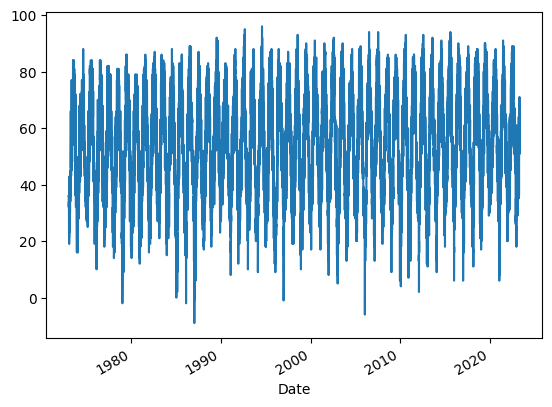

In [16]:
weather["tmax"].plot()

In [23]:
# создадем целевой столбец target используя метод сдвига
weather["target"] = weather.shift(-1)["tavg"]

In [24]:
weather

,tavg,tmax,tmin,prcp,target
Date,,,,,
1973-01-01,25,36.0,14.0,0.00,25.0
1973-01-02,25,36.0,14.0,0.00,23.0
1973-01-03,23,36.0,14.0,0.00,26.0
1973-01-04,26,36.0,23.0,0.00,31.0
1973-01-05,31,36.0,28.0,0.00,31.0
...,...,...,...,...,...
2023-04-22,51,64.0,37.0,0.00,55.0
2023-04-23,55,69.0,38.0,0.00,59.0
2023-04-24,59,71.0,44.0,0.00,53.0


In [25]:
weather = weather.ffill()

In [26]:
weather

,tavg,tmax,tmin,prcp,target
Date,,,,,
1973-01-01,25,36.0,14.0,0.00,25.0
1973-01-02,25,36.0,14.0,0.00,23.0
1973-01-03,23,36.0,14.0,0.00,26.0
1973-01-04,26,36.0,23.0,0.00,31.0
1973-01-05,31,36.0,28.0,0.00,31.0
...,...,...,...,...,...
2023-04-22,51,64.0,37.0,0.00,55.0
2023-04-23,55,69.0,38.0,0.00,59.0
2023-04-24,59,71.0,44.0,0.00,53.0


In [38]:
# инициализируем регрессионную модель
from sklearn.linear_model import Ridge

# указываем параметр alpha, он отвечает за то насколько сильно уменьшаються коэффициенты
rr = Ridge(alpha=.1)

In [39]:
# указываем что в прогнозе будут принимать участие все стобцы за исключением столбца target
predictors = weather.columns[~weather.columns.isin(["target"])]

In [29]:
def backtest(weather, model, predictors, start=3650, step=30):
    all_predictions = []
    
    for i in range(start, weather.shape[0], step):
        train = weather.iloc[:i,:] # указываем тренировочные данные
        test = weather.iloc[i:(i+step),:] # указываем тестовые данные
        
        model.fit(train[predictors], train["target"]) # вносим в модель пресказатели и предсказываемое занчение
        
        preds = model.predict(test[predictors]) # делаем прогноз

        preds = pd.Series(preds, index=test.index) # преобразовываем наш массив numpy в серию pandas c которой удобнее работать
        
        combined = pd.concat([test["target"], preds], axis=1) # комбинируем данные которые спрогнозировала наша модель с тестовыми данными
        combined.columns = ["actual", "prediction"] # указываем названия для колонок
        combined["diff"] = (combined["prediction"] - combined["actual"]).abs() # создаем колонку для определения разницы, если она будет отрицательной то abs сделает положительным
        
        all_predictions.append(combined)
    return pd.concat(all_predictions) # возвращаем обьедененные данные

In [37]:
# используем нашу фунцию предав необходимые значения
predictions = backtest(weather, rr, predictors) 

In [36]:
# выводим информацию о средней погрешности в прогнозах она сотсавила 3.31 градус по Фарингейту
from sklearn.metrics import mean_absolute_error, mean_squared_error

mean_absolute_error(predictions["actual"], predictions["prediction"])

3.310677514589268

In [32]:
# выведем отсортированные значения от большей погрешности к меньшей 
predictions.sort_values("diff", ascending=False)

,actual,prediction,diff
Date,,,
1987-01-28,-4.0,22.294414,26.294414
1985-02-07,3.0,28.795425,25.795425
1987-01-06,-9.0,16.767392,25.767392
2020-05-11,39.0,63.255692,24.255692
1991-01-29,8.0,31.804017,23.804017
...,...,...,...
2007-11-25,34.0,33.998383,0.001617
1983-01-16,30.0,30.001303,0.001303
1997-02-05,32.0,31.999367,0.000633


<Axes: >

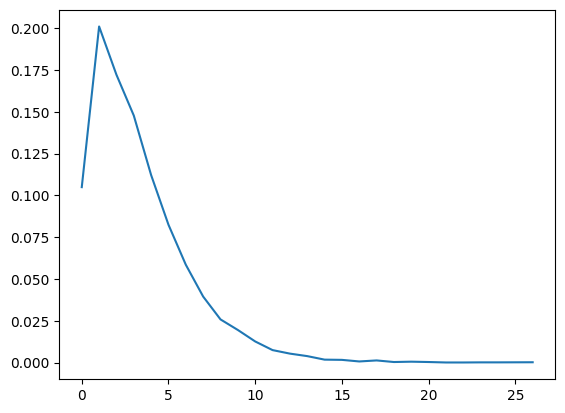

In [40]:
# выведем график по которому менялась наша diff - разница
(predictions["diff"].round().value_counts().sort_index() / predictions.shape[0]).plot()

In [34]:
predictions

,actual,prediction,diff
Date,,,
1983-01-01,32.0,32.305022,0.305022
1983-01-02,34.0,31.318502,2.681498
1983-01-03,31.0,33.470720,2.470720
1983-01-04,36.0,30.957390,5.042610
1983-01-05,36.0,36.337936,0.337936
...,...,...,...
2023-04-22,55.0,51.850217,3.149783
2023-04-23,59.0,56.080523,2.919477
2023-04-24,53.0,59.313093,6.313093
